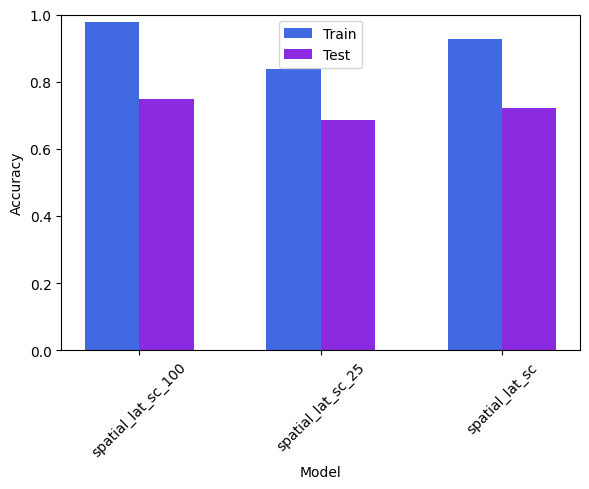

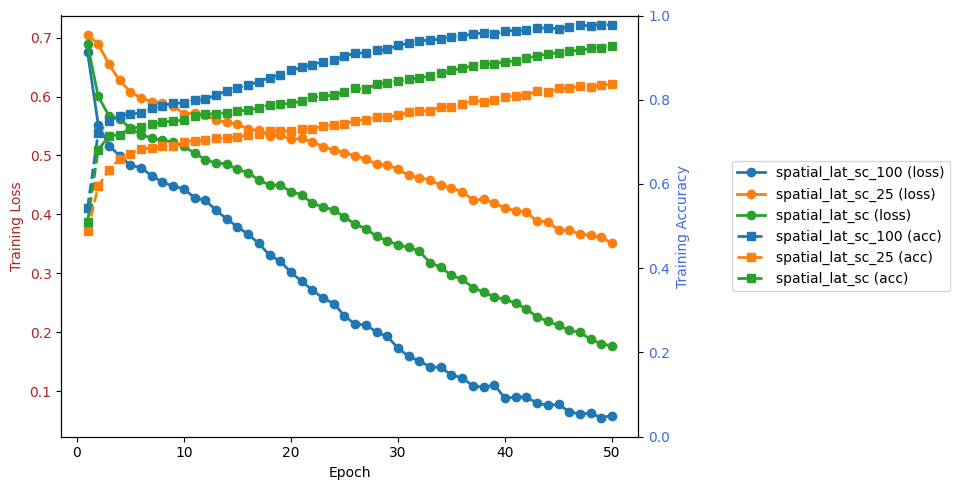

In [ ]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np

from viz_util import colors

files = sorted(glob('../output_results/E_sent/main-2/*.json'))
if not files:
    raise FileNotFoundError('No matching files found')
files.append('../output_results/E_sent/main/lat_sc_2026-04-30_08-23-34_e-50_s-30_spatial.json')

file_labels = []
train_accuracies = []
test_accuracies = []
epoch_losses_list = []
epoch_accuracies_list = []

for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).name
    file_labels.append('_'.join([data.get('training_config', {}).get('input_mode'), data.get('training_config', {}).get('output_file_prefix') or 'poisson_sc']))
    train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    test_accuracies.append(data['results']['test_accuracy'])
    epoch_losses_list.append(data['results']['epoch_train_loss'])
    epoch_accuracies_list.append(data['results']['epoch_train_accuracy'])

# First plot: bar chart
x = np.arange(len(files))
width = 0.3

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - width / 2, train_accuracies, width, label='Train', color=colors.train_accuracy)
ax.bar(x + width / 2, test_accuracies, width, label='Test', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(file_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Second plot: lines with dual y-axis (loss and accuracy over epochs)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot loss on left y-axis
for loss_vals, label in zip(epoch_losses_list, file_labels):
    epochs = np.arange(1, len(loss_vals) + 1)
    ax1.plot(epochs, loss_vals, marker='o', label=f'{label} (loss)', linewidth=2)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=colors.loss)
ax1.tick_params(axis='y', labelcolor=colors.loss)

# Create right y-axis for accuracy
ax2 = ax1.twinx()
for acc_vals, label in zip(epoch_accuracies_list, file_labels):
    epochs = np.arange(1, len(acc_vals) + 1)
    ax2.plot(epochs, acc_vals, marker='s', linestyle='--', label=f'{label} (acc)', linewidth=2)

ax2.set_ylabel('Training Accuracy', color=colors.train_accuracy)
ax2.tick_params(axis='y', labelcolor=colors.train_accuracy)
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', bbox_to_anchor=(1.15, 0.5))

plt.tight_layout()
plt.show()


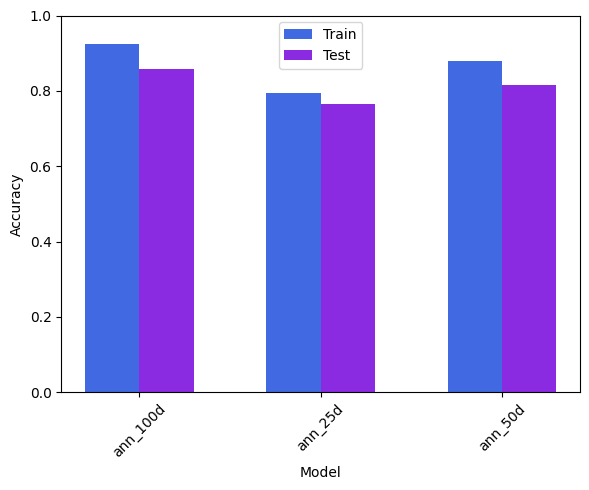

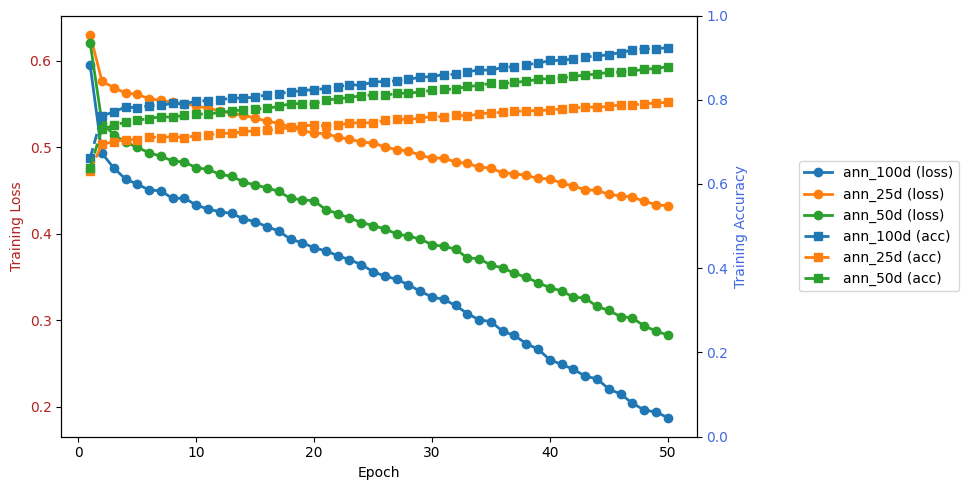

In [ ]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np

from viz_util import colors

files = sorted(glob('../output_results/E_sent/ANN/*.json'))
if not files:
    raise FileNotFoundError('No matching files found')

file_labels = []
train_accuracies = []
test_accuracies = []
epoch_losses_list = []
epoch_accuracies_list = []

for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).name
    file_labels.append('_'.join(str(Path(file_path).stem).split('_')[0:2]))
    train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    test_accuracies.append(data['results']['test_accuracy'])
    epoch_losses_list.append(data['results']['epoch_train_loss'])
    epoch_accuracies_list.append(data['results']['epoch_train_accuracy'])

# First plot: bar chart
x = np.arange(len(files))
width = 0.3

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - width / 2, train_accuracies, width, label='Train', color=colors.train_accuracy)
ax.bar(x + width / 2, test_accuracies, width, label='Test', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(file_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Second plot: lines with dual y-axis (loss and accuracy over epochs)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot loss on left y-axis
for loss_vals, label in zip(epoch_losses_list, file_labels):
    epochs = np.arange(1, len(loss_vals) + 1)
    ax1.plot(epochs, loss_vals, marker='o', label=f'{label} (loss)', linewidth=2)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=colors.loss)
ax1.tick_params(axis='y', labelcolor=colors.loss)

# Create right y-axis for accuracy
ax2 = ax1.twinx()
for acc_vals, label in zip(epoch_accuracies_list, file_labels):
    epochs = np.arange(1, len(acc_vals) + 1)
    ax2.plot(epochs, acc_vals, marker='s', linestyle='--', label=f'{label} (acc)', linewidth=2)

ax2.set_ylabel('Training Accuracy', color=colors.train_accuracy)
ax2.tick_params(axis='y', labelcolor=colors.train_accuracy)
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', bbox_to_anchor=(1.15, 0.5))

plt.tight_layout()
plt.show()


# NEURON MODEL

../output_results/E_sent/neuron_model\lat_sc_100_qlif_2026-05-01_16-21-28_e-50_s-30_spatial.pt
Evaluation | samples=2085 | loss=1.5181 | acc=0.7353 | eval_time_ms=3972.49
Average AC operations per sample: 411589.25
Average energy per sample: 10549032.07 pJ (10549.0321 nJ)
3972.492200322449
../output_results/E_sent/neuron_model\lat_sc_100_synaptic_2026-05-01_16-54-20_e-50_s-30_spatial.pt
Evaluation | samples=2085 | loss=1.1727 | acc=0.7871 | eval_time_ms=4194.49
Average AC operations per sample: 215150.89
Average energy per sample: 5514317.15 pJ (5514.3171 nJ)
4194.487299770117
../output_results/E_sent/neuron_model\lat_sc_100_synaptic_learn_2026-05-01_18-40-11_e-50_s-30_spatial.pt
Evaluation | samples=2085 | loss=1.4683 | acc=0.7655 | eval_time_ms=4261.33
Average AC operations per sample: 203338.47
Average energy per sample: 5211564.96 pJ (5211.5650 nJ)
4261.332099325955
../output_results/E_sent/main-2/lat_sc_100_2026-04-30_11-03-04_e-50_s-30_spatial.pt
Evaluation | samples=2085 | loss=

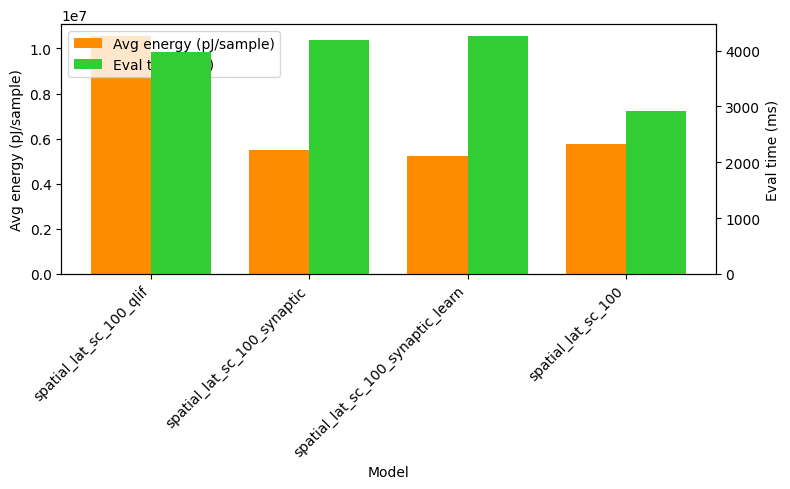

In [ ]:
from E_sent_eval import evaluate_model
from glob import glob
from pathlib import Path
import json
from argparse import Namespace

import matplotlib.pyplot as plt
import numpy as np
from viz_util import colors

models = sorted(glob('../output_results/E_sent/neuron_model/*.pt'))
models.append('../output_results/E_sent/main-2/lat_sc_100_2026-04-30_11-03-04_e-50_s-30_spatial.pt') # the LIF 100d model

labels = []
avg_energy_pj_per_sample = []
eval_time_ms = []

for model_path in models:
    meta_path = Path(model_path).with_suffix('.json')
    meta = json.loads(meta_path.read_text()).get('training_config', {})
    args = Namespace(**(meta | {
        "model_path": model_path,
        "diagnose": False,
        # "diagnose": True,
        # "limit": 10,
        "limit": None,
        "split": "test",
        "estimate_energy": True,
        "energy_ac_cost_pj": 25.63,
        "output_json": None,
    }))
    # Try to cast each number-like argument to int if possible, since JSON doesn't distinguish.
    args = Namespace(**{k: (int(v) if isinstance(v, str) and v.isdigit() else v) for k, v in vars(args).items()})
    print(model_path)
    results = evaluate_model(args)
    labels.append('_'.join([meta.get('input_mode'), meta.get('output_file_prefix') or 'poisson_sc']))
    avg_energy_pj_per_sample.append(results['avg_energy_pj_per_sample'])
    eval_time_ms.append(results.get('eval_time_ms', 0))
    print(results['eval_time_ms'])

positions = np.arange(len(labels))
width = 0.38

fig, ax1 = plt.subplots(figsize=(max(8, len(labels) * 1.2), 5))
ax2 = ax1.twinx()

bars_energy = ax1.bar(positions - width/2, avg_energy_pj_per_sample, width, color=colors.energy, label='Avg energy (pJ/sample)')
bars_time = ax2.bar(positions + width/2, eval_time_ms, width, color=colors.time, label='Eval time (ms)')

ax1.set_xlabel('Model')
ax1.set_ylabel('Avg energy (pJ/sample)')
ax2.set_ylabel('Eval time (ms)')
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.tick_params(axis='y')
ax2.tick_params(axis='y')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()